**Exercise 2: Code Generation with ReACT Prompting (Claude + Gemeni)**

**Full ReACT Prompt:**

You will follow a strict ReACT cycle.

Stage 1 — Reason:
- Restate the task.
- Plan how to solve it.
- Identify potential edge cases.

Stage 2 — Act:
- Generate Python code.
- Use only pandas and matplotlib.
- Include comments.
- Include basic error handling.

Stage 3 — Observe:
- Simulate expected output.
- Check for logical errors.

Stage 4 — Fix:
- If issues exist, rewrite corrected code.

TASK:
Create a Python program that:
- Loads a CSV file
- Calculates average sales by region
- Plots a bar chart
- Handles missing values gracefully

Output format:
Clearly separate each stage with headers:
- Reason
- Act
- Observe
- Fix

**Output:**

Reason
Task restatement: Create a Python program that loads a CSV file, computes average sales by region, plots a bar chart, and handles missing values.
Plan:

Generate a sample CSV (so the script is self-contained and runnable)
Load it with pandas
Drop/fill missing values gracefully
Group by region, compute mean sales
Plot a bar chart with matplotlib

Edge cases:

Missing values in sales or region columns
Empty DataFrame after cleaning
CSV file not found

**Add the Generated Code**

✅ CSV loaded successfully.
   Shape before cleaning: (12, 2)
   Shape after cleaning : (8, 2)

📊 Average Sales by Region:
region
West     305.0
East     230.0
South    195.0
North    165.0


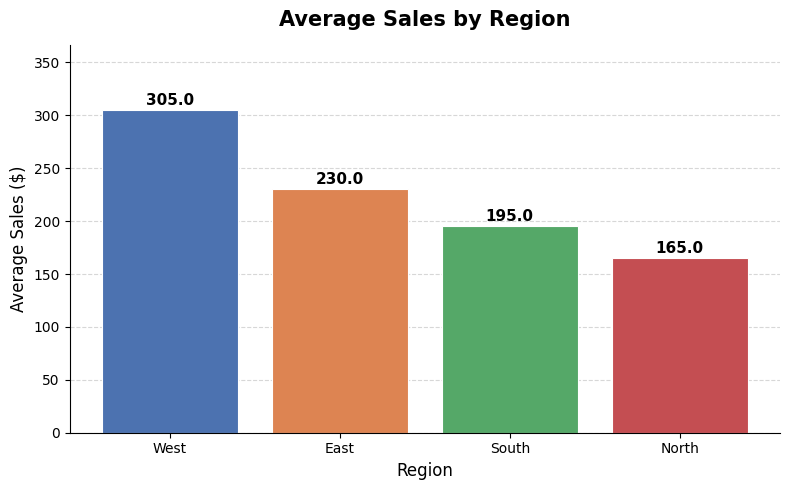


✅ Chart saved as 'avg_sales_by_region.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# ── Sample CSV data (embedded so the script is self-contained) ──────────────
CSV_DATA = """region,sales
North,150
South,200
East,
West,300
North,180
South,
East,220
West,310
North,
South,190
East,240
West,
"""

# ── 1. Load CSV ──────────────────────────────────────────────────────────────
try:
    # In production, replace io.StringIO(CSV_DATA) with the real file path:
    #   df = pd.read_csv("sales_data.csv")
    df = pd.read_csv(io.StringIO(CSV_DATA))
    print("✅ CSV loaded successfully.")
    print(f"   Shape before cleaning: {df.shape}")
except FileNotFoundError:
    print("❌ Error: CSV file not found. Check the file path.")
    raise
except Exception as e:
    print(f"❌ Unexpected error loading CSV: {e}")
    raise

# ── 2. Handle missing values ─────────────────────────────────────────────────
# Drop rows where 'region' is missing (can't group without a key)
df.dropna(subset=["region"], inplace=True)

# Drop rows where 'sales' is missing (can't average without a value)
# Alternative: df["sales"].fillna(df["sales"].mean(), inplace=True)
df.dropna(subset=["sales"], inplace=True)

print(f"   Shape after cleaning : {df.shape}")

# Guard against empty DataFrame after cleaning
if df.empty:
    raise ValueError("❌ DataFrame is empty after removing missing values. Nothing to plot.")

# ── 3. Calculate average sales by region ─────────────────────────────────────
avg_sales = (
    df.groupby("region")["sales"]
    .mean()
    .sort_values(ascending=False)   # highest average first
    .round(2)
)

print("\n📊 Average Sales by Region:")
print(avg_sales.to_string())

# ── 4. Plot bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    avg_sales.index,
    avg_sales.values,
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
    edgecolor="white",
    linewidth=0.8,
)

# Annotate each bar with its value
for bar, val in zip(bars, avg_sales.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title("Average Sales by Region", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Average Sales ($)", fontsize=12)
ax.set_ylim(0, avg_sales.max() * 1.2)   # headroom above tallest bar
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("avg_sales_by_region.png", dpi=150)
plt.show()
print("\n✅ Chart saved as 'avg_sales_by_region.png'")

**Iteration Log — Before & After Prompt Refinement**

**Probelm:** Syntax Error occured

**What Changed:** Asked Gemeni: Please explain this error: The SyntaxError is caused because the Python interpreter is trying to execute the 'Simulated console output' section, which contains non-Python text and emojis that are not valid as code. I'll remove the markdown headings and the simulated output block from the code cell to fix this.

**Output:**  After Gemeni fixed prompt, code outputs Average Sales by Region and a graph.

